In [1]:
""" Module Summary: Data Science
    Goal: Data Analytics
    
    Learning Outcomes:
    1. Data Analytics Workflow
    2. Data Dashboard
    3. Data Insights
    
    Project Assignment: Churn Prediction
    
""";
print("Good Bye, Data Science.")

Good Bye, Data Science.


In [2]:
""" Class 11. Introduction to Machine Learning

Objectives:
1. AI vs Data Science vs Machine Learning vs Deep Learning (Done)
2. Understand DS/ML/DL Workflow (Done)
3. How machine learns from data.


AI = Any system that mimics human behaviour.
DS = A branch of AI that uses data to predict future behaviour.
ML = A branch of DS that uses hand-engineered features.
DL = A branch of ML that automatically learns from the data using a neural network.


Machine Learning Tasks Categories:
1. Computer Vision (Image classification, image segmentation,..)
2. Natural Language Processing
3. Audio 
4. Multimodal

Project: Butterfly Classification
Task: Computer vision - Image Classification

1. Write down some SMART research questions.
   S - Specific
   M - Measurable
   A - Achievable
   R - Relevant
   T - Time Bound
2. Organize the research questions and distribute (if team available).
   R1, R2, R3, R4, R5 may be organized as R3 > R1 > R5 > R4 > R2
   - Distribute the RQs evenly among team mates
3. Create Search Queries to filter 3-5 latest relevant Papers to your RQ.
4. Perform literature review on the RQ.
   If RQ is already answered -> pass the RQ
   If RQ is partially or no addressed -> scope
5. Design experiment for the RQ
   Data
   Model
   Training
   Evaluation
6. Result Analysis (Root-Cause-Analysis) and Gap Identification
7. Propose a novel solution to solve the gaps
""" 
import pandas as pd
import seaborn as sns
import numpy as np

In [4]:
import os

ROOT_DIR = "E:\\PyCharmProjects\\pythonProject\\"
DATA_DIR = os.path.join(ROOT_DIR, "data")

print(ROOT_DIR)
print(DATA_DIR)

E:\PyCharmProjects\pythonProject\
E:\PyCharmProjects\pythonProject\data


In [6]:
dataset_file = os.path.join(
    DATA_DIR, 
    "housing_single_feature.csv"
)

print(dataset_file)

E:\PyCharmProjects\pythonProject\data\housing_single_feature.csv


In [7]:
house_df = pd.read_csv(dataset_file)
house_df.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [8]:
""" Task: Tabular - Regression
Predict price from a given area.

estimated_price = per_sqft_price * area + registration_fee

"""

# Step 1. Parameter initialization
per_sft_price = np.random.randint(1, 1000000)
registration_cost = np.random.randint(1, 1000000)
print(per_sft_price)
print(registration_cost)

421010
129395


In [10]:
# Step 2: Define the ML Algorithm
def get_house_price(area, per_sft_price, registration_cost):
    estimated_price = per_sft_price * area + registration_cost
    return estimated_price

In [13]:
estimated_price = get_house_price(
    area=7420,
    per_sft_price=per_sft_price,
    registration_cost=registration_cost,
)

print("Original_price", house_df.iloc[0]['price'])
print("estimated_price",estimated_price)

Original_price 13300000
estimated_price 3124023595


In [14]:
# Step 3. Predict the result
house_df['estimated_price'] = [
    get_house_price(area, per_sft_price, registration_cost) for area in house_df['area']
]

house_df.head()

,area,price,estimated_price
0,7420,13300000,3124023595
1,8960,12250000,3772378995
2,9960,12250000,4193388995
3,7500,12215000,3157704395
4,7420,11410000,3124023595


In [15]:
""" Demonstration purposes only """

x = []
y = []
y_type = []

for i in range(len(house_df)):
    x.append(house_df.iloc[i]["area"])
    y.append(house_df.iloc[i]["price"])
    y_type.append("y_true")
    
    x.append(house_df.iloc[i]["area"])
    y.append(house_df.iloc[i]["estimated_price"])
    y_type.append("y_pred")
    
house_df = pd.DataFrame({
    "area": np.array(x),
    "price": np.array(y),
    "type": np.array(y_type)
})

print(len(house_df))
house_df.head()

1090


,area,price,type
0,7420,13300000,y_true
1,7420,3124023595,y_pred
2,8960,12250000,y_true
3,8960,3772378995,y_pred
4,9960,12250000,y_true


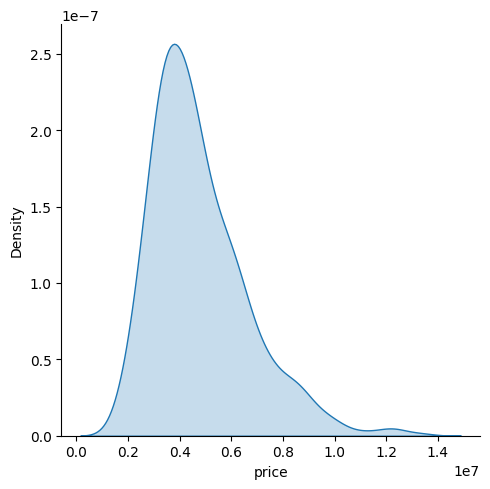

In [16]:
""" Probability Distribution Function (PDF) for actual house price given in the dataset """
sns.displot(
    data=house_df.query("type == 'y_true'"),
    x="price",
    kind='kde',
    fill=True,
)

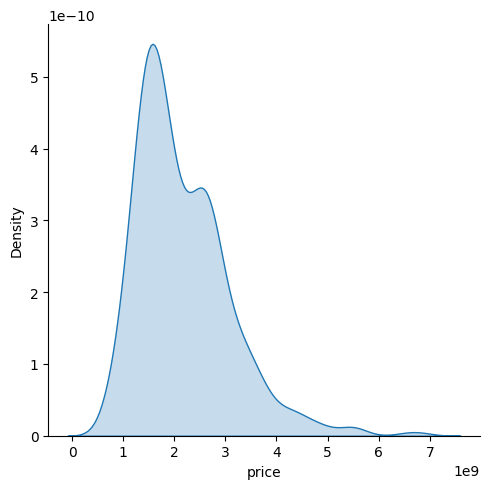

In [17]:
sns.displot(
    data=house_df.query("type == 'y_pred'"),
    x="price",
    kind='kde',
    fill=True,
)

In [ ]:
from scipy.stats import entropy

"""
KL divergence: measures the dissimilarity between two distributions
  KLD = 0 : Same distribution

"""

def calculate_kl_divergence(df, epsilon=1e-10, max_divergence=1e6):
    y_pred = df[df["type"] == "y_pred"]["price"].values
    y_true = df[df["type"] == "y_true"]["price"].values
    
    y_pred_prob = y_pred / np.sum(y_pred)
    y_true_prob = y_true / np.sum(y_true)
    
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1)
    y_true_prob = np.clip(y_true_prob, epsilon, 1)
    
    kl_div = entropy(y_true_prob, y_pred_prob)
    
    if np.isinf(kl_div):
        kl_div = max_divergence
    
    return kl_div

kl_divergence = calculate_kl_divergence(house_df)
print(f"KL Divergence: {kl_divergence}")

In [ ]:
"""
Data Generating Process / System: Actual entity who generates the true generate
ML tries to mimic a fake-data-generating process that matches the distribution
of the actual data generating process.

Find the distribution dissimilarities between y_true_PDF and y_pred_PDF

KL Divergence = D(y_true_PDF || y_pred_PDF)

Objective of any Machine Learning
---------------------------------
- Increase Maximum likelihood estimation
- Reduce dissimilarity between distributions (predicted vs true) 
- Reduce KL divergence
- Minimize some error / loss / cost objective function
""";